<a href="https://colab.research.google.com/github/kennethkvs/RetinalDiseasesOCTClassifier/blob/main/RetinalDiseaseOCTClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retinal Disease OCT Classifier (COMPSCI 4AL3 Assignment)


In [35]:
# Imports
import os
import numpy as np
import pandas as pd
from PIL import Image
import sklearn
import matplotlib.pyplot as plt
# PyTorch Imports
import torch
from torchvision.transforms import v2 as image_preprocess
from torch.utils.data import DataLoader

In [36]:
# Dataset Class Definition
class OCTImageDataset:
    def __init__(self, data_dir: str, type: str):
        self.data_dir = data_dir
        self.type = type
        self.label_mapping = {
            'CNV': 0,
            'DME': 1,
            'DRUSEN': 2,
            'NORMAL': 3
        }
        self.image_paths = []
        self.classes = list(self.label_mapping.keys())
        self.labels = []
        self.image_processor = None

        # Initialize class attributes
        match type:
            case 'train':
                self.image_processor = image_preprocess.Compose([
                    # Convert to tensor since input is a PIL image
                    image_preprocess.ToImage(), 
                    image_preprocess.ToDtype(torch.uint8, scale=True),
                    # Crop
                    image_preprocess.Resize((224, 224), antialias=True),
                    # Different transformations
                    image_preprocess.RandomHorizontalFlip(),
                    # Normalize
                    image_preprocess.ToDtype(torch.float32, scale=True),  # Normalize expects float input according to docs
                    image_preprocess.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                ])
            case 'test' | 'val':
                self.image_processor = image_preprocess.Compose([
                    # Convert to tensor since input is a PIL image
                    image_preprocess.ToImage(), 
                    image_preprocess.ToDtype(torch.uint8, scale=True),
                    # Crop
                    image_preprocess.Resize((224, 224), antialias=True),
                    # Normalize
                    image_preprocess.ToDtype(torch.float32, scale=True),  # Normalize expects float input according to docs
                    image_preprocess.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                ])
            case _:
                raise ValueError("Type must be 'train', 'val', or 'test'.")
        self.load_data()

    def load_data(self):
        for label in os.listdir(self.data_dir):
            label_dir = os.path.join(self.data_dir, label)
            if os.path.isdir(label_dir):
                for image_file in os.listdir(label_dir):
                    if image_file.endswith(('.png', '.jpg', '.jpeg')):
                        image_path = os.path.join(label_dir, image_file)
                        self.image_paths.append(image_path)
                        self.labels.append(self.label_mapping[label])
        
        print(f"Loaded {len(self.image_paths)} images for {self.type} set.")

    def visualize(self):
        # Print out dataset statistics
        class_counts = {
            'CNV': self.labels.count(0),
            'DME': self.labels.count(1),
            'DRUSEN': self.labels.count(2),
            'NORMAL': self.labels.count(3)
        }
        print(f"Visualizing dataset statistics for {self.type} set:")
        for class_name, count in class_counts.items():
            print(f"{class_name}: {count} images")
        
        # Plot class distribution
        plt.bar(class_counts.keys(), class_counts.values())
        plt.title(f'Class Distribution in {self.type} Set')
        plt.xlabel('Classes')
        plt.ylabel('Number of Images')
        plt.show()

        # Display sample images from each class
        plt.figure(figsize=(12, 6))
        for class_name in self.classes:
            # Pick the first image from each class for visualization
            image_path = os.path.join(self.data_dir, class_name, os.listdir(os.path.join(self.data_dir, class_name))[0])
            image = Image.open(image_path)
            plt.subplot(1, 4, self.label_mapping[class_name] + 1)
            plt.imshow(image, cmap='gray') # Image data is grayscale idk why without cmap it isn't grayscale
            plt.title(class_name)
        plt.show()

    # Needed for PyTorch DataLoader compatibility
    def __len__(self):
        if len(self.image_paths) != len(self.labels):
            raise ValueError("Mismatch between number of images and labels.")
        if len(self.image_paths) == 0 or len(self.labels) == 0:
            raise ValueError("No images found in the dataset.")

        return len(self.image_paths)
    
    # Needed for PyTorch DataLoader compatibility
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(image_path).convert('RGB')
        if self.image_processor:
            image = self.image_processor(image)
        else:
            raise ValueError("Image processor not defined.")
        
        return image, label


In [40]:
# Data Configurations
batch_size = 64
shuffle_data = True
train_data_dir = 'Dataset/train'
test_data_dir = 'Dataset/test'
val_data_dir = 'Dataset/val'

Loaded 83484 images for train set.
Visualizing dataset statistics for train set:
CNV: 37205 images
DME: 11348 images
DRUSEN: 8616 images
NORMAL: 26315 images


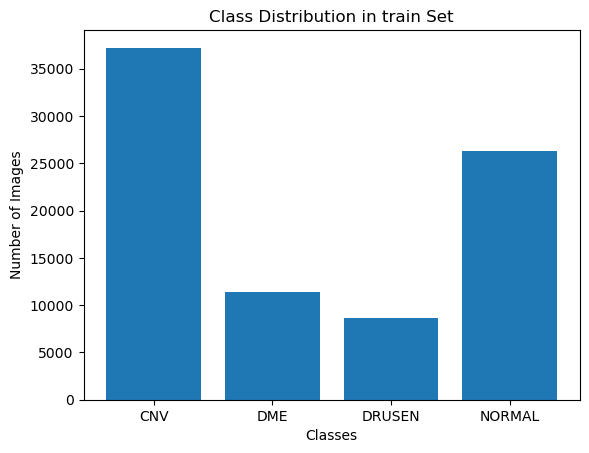

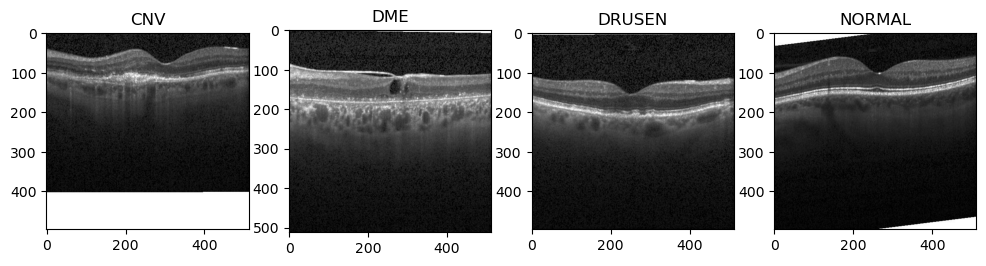

Sample training data tensor
(Image([[[-1.7583, -1.4843, -1.4672,  ..., -1.7069, -1.8268, -1.8097],
        [-1.6555, -1.3987, -1.4843,  ..., -1.4672, -1.7754, -1.9295],
        [-1.4843, -1.6042, -1.7240,  ..., -1.5699, -1.7754, -1.8439],
        ...,
        [ 2.2489,  2.2489,  2.2489,  ...,  2.2489,  2.2489,  2.2489],
        [ 2.2489,  2.2489,  2.2489,  ...,  2.2489,  2.2489,  2.2489],
        [ 2.2489,  2.2489,  2.2489,  ...,  2.2489,  2.2489,  2.2489]],

       [[-1.6681, -1.3880, -1.3704,  ..., -1.6155, -1.7381, -1.7206],
        [-1.5630, -1.3004, -1.3880,  ..., -1.3704, -1.6856, -1.8431],
        [-1.3880, -1.5105, -1.6331,  ..., -1.4755, -1.6856, -1.7556],
        ...,
        [ 2.4286,  2.4286,  2.4286,  ...,  2.4286,  2.4286,  2.4286],
        [ 2.4286,  2.4286,  2.4286,  ...,  2.4286,  2.4286,  2.4286],
        [ 2.4286,  2.4286,  2.4286,  ...,  2.4286,  2.4286,  2.4286]],

       [[-1.4384, -1.1596, -1.1421,  ..., -1.3861, -1.5081, -1.4907],
        [-1.3339, -1.0724, -1.1

In [41]:
# Training Dataset Initialization
training_data = OCTImageDataset(data_dir=train_data_dir, type='train')
training_data.visualize()
print(f'Sample training data tensor\n{training_data[0]}')

# Training Data Loader
training_data_loader = DataLoader(dataset=training_data, batch_size=batch_size, shuffle=shuffle_data)

Loaded 968 images for test set.
Visualizing dataset statistics for test set:
CNV: 242 images
DME: 242 images
DRUSEN: 242 images
NORMAL: 242 images


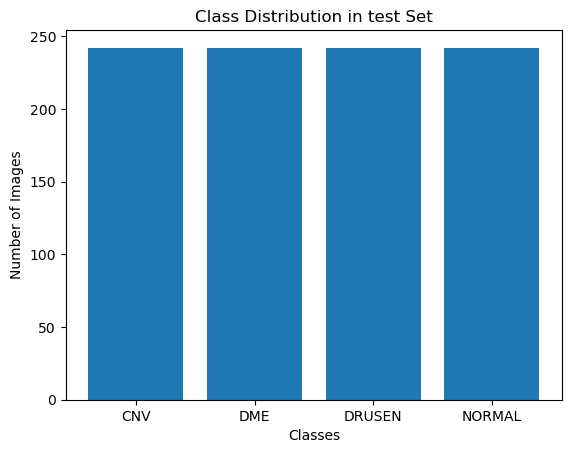

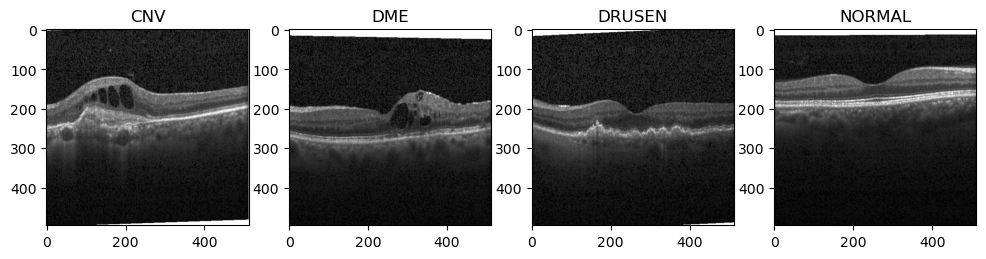

Sample testing data tensor
(Image([[[ 2.2318,  2.2147,  2.1975,  ..., -1.8097, -1.9295, -0.4911],
        [ 1.3584,  1.4098,  1.3584,  ..., -1.6555, -1.8439, -0.4911],
        [-1.4672, -1.3815, -1.6384,  ..., -1.7412, -1.9467, -0.4739],
        ...,
        [-1.9467, -1.9638, -1.9124,  ...,  2.2489,  2.2489,  2.2489],
        [-2.0152, -1.8953, -1.9124,  ...,  2.2489,  2.2489,  2.2489],
        [-1.9809, -2.0152, -2.0152,  ...,  2.2489,  2.2489,  2.2489]],

       [[ 2.4111,  2.3936,  2.3761,  ..., -1.7206, -1.8431, -0.3725],
        [ 1.5182,  1.5707,  1.5182,  ..., -1.5630, -1.7556, -0.3725],
        [-1.3704, -1.2829, -1.5455,  ..., -1.6506, -1.8606, -0.3550],
        ...,
        [-1.8606, -1.8782, -1.8256,  ...,  2.4286,  2.4286,  2.4286],
        [-1.9307, -1.8081, -1.8256,  ...,  2.4286,  2.4286,  2.4286],
        [-1.8957, -1.9307, -1.9307,  ...,  2.4286,  2.4286,  2.4286]],

       [[ 2.6226,  2.6051,  2.5877,  ..., -1.4907, -1.6127, -0.1487],
        [ 1.7337,  1.7860,  1.73

In [44]:
# Testing Dataset Initialization
testing_data = OCTImageDataset(data_dir=test_data_dir, type='test')
testing_data.visualize()
print(f'Sample testing data tensor\n{testing_data[0]}')

# Testing Data Loader
testing_data_loader = DataLoader(dataset=testing_data, batch_size=batch_size, shuffle=shuffle_data)

Loaded 32 images for val set.
Visualizing dataset statistics for val set:
CNV: 8 images
DME: 8 images
DRUSEN: 8 images
NORMAL: 8 images


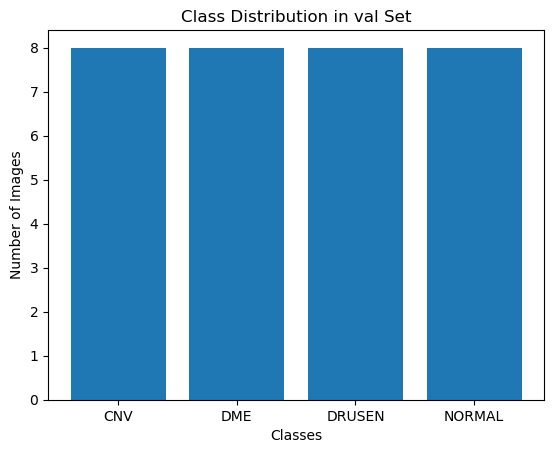

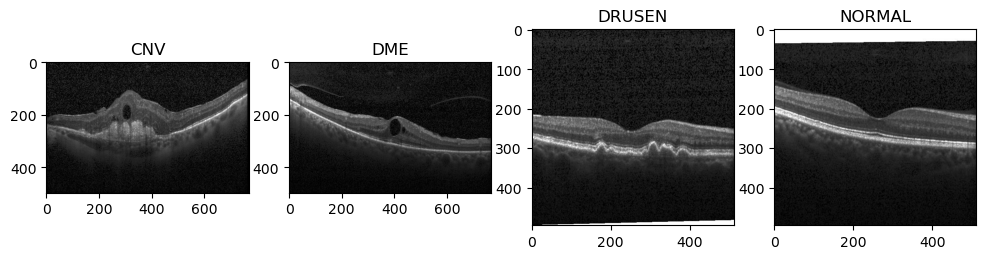

Sample validation data tensor
(Image([[[-1.8268, -1.4843, -1.6213,  ..., -1.6555, -2.0323, -2.1179],
        [-1.7412, -1.6384, -1.6898,  ..., -1.6898, -1.9809, -2.1008],
        [-1.7240, -1.8268, -1.5870,  ..., -1.8953, -1.9980, -2.1008],
        ...,
        [-2.0665, -2.0665, -2.0665,  ..., -2.0665, -2.1179, -2.1179],
        [-2.0665, -2.0323, -2.0152,  ..., -2.0665, -2.1179, -2.1179],
        [-2.0494, -2.0494, -2.0665,  ..., -2.0837, -2.1179, -2.1179]],

       [[-1.7381, -1.3880, -1.5280,  ..., -1.5630, -1.9482, -2.0357],
        [-1.6506, -1.5455, -1.5980,  ..., -1.5980, -1.8957, -2.0182],
        [-1.6331, -1.7381, -1.4930,  ..., -1.8081, -1.9132, -2.0182],
        ...,
        [-1.9832, -1.9832, -1.9832,  ..., -1.9832, -2.0357, -2.0357],
        [-1.9832, -1.9482, -1.9307,  ..., -1.9832, -2.0357, -2.0357],
        [-1.9657, -1.9657, -1.9832,  ..., -2.0007, -2.0357, -2.0357]],

       [[-1.5081, -1.1596, -1.2990,  ..., -1.3339, -1.7173, -1.8044],
        [-1.4210, -1.3164, -1

In [45]:
# Validation Dataset Initialization
val_data = OCTImageDataset(data_dir=val_data_dir, type='val')
val_data.visualize()
print(f'Sample validation data tensor\n{val_data[0]}')

# Training Data Loader
val_data_loader = DataLoader(dataset=val_data, batch_size=batch_size, shuffle=shuffle_data)